In [1]:
!pip install nltk pandas

In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/WuraolaOyewusi/Health-Related-Headlines-Datasets-for-Natural-Language-Processing/master/Health_Related_Headlines_Dataset.csv"

df = pd.read_csv(url)

df.head()

,Date,Source,Headlines,Teaser,Category
0,"January, 1970",Medscape Special Reports,Special Report: Adult Vaccines -- New ACIP Rec...,New recommendations for already approved vacci...,Immunization
1,"January, 1970",Medscape Medical News,Combined Internet and Telephone Intervention M...,"In a randomized trial, combined Internet and t...",Substance Abuse and Addiction
2,"April, 1997",Medscape Psychiatry & Mental Health eJournal [TM],Link Between Parental Alcoholism and Childhood...,It is proposed that depressed children identif...,Substance Abuse and Addiction
3,"November, 1997",Medscape Psychiatry & Mental Health eJournal [TM],Methadone Dose in the Treatment of Opiate Depe...,The epidemic of heroin abuse within the US has...,Substance Abuse and Addiction
4,"March, 2000",Medscape Medical News,Magnet Treatment Had No Beneficial Effect on P...,A small study using one variety of magnet for ...,Pain Management


In [8]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (39405, 5)

Columns:
['Date', 'Source', 'Headlines', 'Teaser', 'Category']


In [9]:
df['text'] = df['Headlines'].astype(str)

df[['Headlines', 'text']].head()

,Headlines,text
0,Special Report: Adult Vaccines -- New ACIP Rec...,Special Report: Adult Vaccines -- New ACIP Rec...
1,Combined Internet and Telephone Intervention M...,Combined Internet and Telephone Intervention M...
2,Link Between Parental Alcoholism and Childhood...,Link Between Parental Alcoholism and Childhood...
3,Methadone Dose in the Treatment of Opiate Depe...,Methadone Dose in the Treatment of Opiate Depe...
4,Magnet Treatment Had No Beneficial Effect on P...,Magnet Treatment Had No Beneficial Effect on P...


In [10]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [12]:
import re
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [13]:
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [14]:
df[['Headlines', 'cleaned_text']].head(10)

,Headlines,cleaned_text
0,Special Report: Adult Vaccines -- New ACIP Rec...,special report adult vaccine new acip recommen...
1,Combined Internet and Telephone Intervention M...,combined internet telephone intervention may f...
2,Link Between Parental Alcoholism and Childhood...,link parental alcoholism childhood mood disorder
3,Methadone Dose in the Treatment of Opiate Depe...,methadone dose treatment opiate dependence
4,Magnet Treatment Had No Beneficial Effect on P...,magnet treatment beneficial effect patient chr...
5,Ask the Experts - Investigational Agents for M...,ask expert investigational agent mesothelioma
6,Estrogen Replacement May Negate the Benefits o...,estrogen replacement may negate benefit growth...
7,MEDLINE Abstracts: Thalidomide Clinical Trials,medline abstract thalidomide clinical trial
8,IRB/FDA Requirements Relevant to HIV/AIDS Clin...,irbfda requirement relevant hivaids clinical t...
9,HIV Clinical Trials in Correctional Settings: ...,hiv clinical trial correctional setting right ...


In [15]:
all_words = ' '.join(df['cleaned_text'])

In [16]:
from collections import Counter

word_list = all_words.split()
word_freq = Counter(word_list)

print("Total unique words:", len(word_freq))
print("\nTop 20 most frequent words:")
print(word_freq.most_common(20))

Total unique words: 18141

Top 20 most frequent words:
[('patient', 2781), ('risk', 2471), ('cancer', 2406), ('pain', 2303), ('drug', 2197), ('new', 1729), ('vaccine', 1586), ('may', 1566), ('use', 1544), ('fda', 1480), ('treatment', 1441), ('disease', 1186), ('opioid', 1152), ('therapy', 1143), ('care', 959), ('u', 866), ('linked', 856), ('chronic', 808), ('trial', 802), ('child', 732)]


In [17]:
!pip install wordcloud

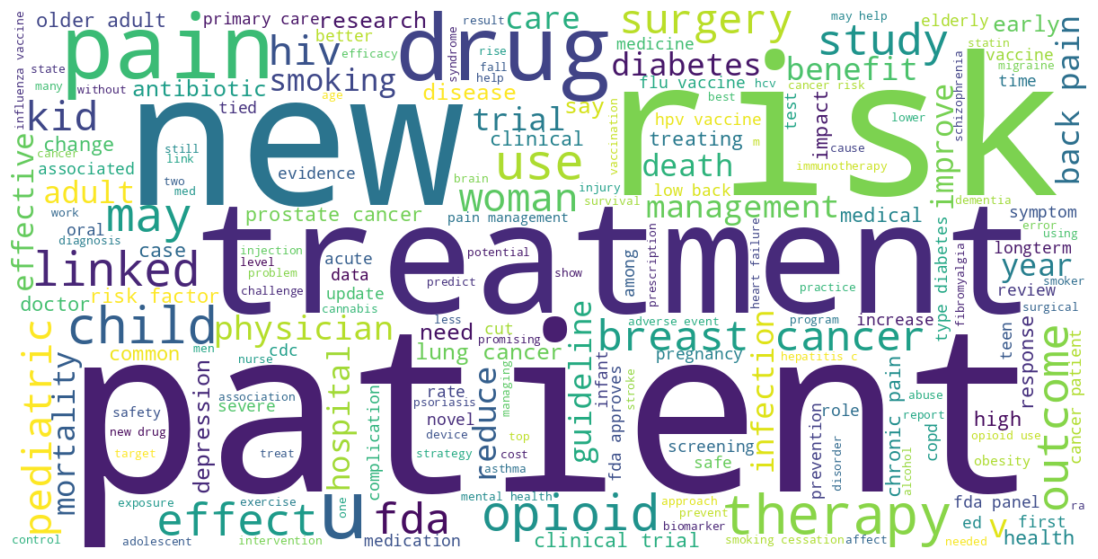

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [19]:
top_20 = word_freq.most_common(20)

words = [item[0] for item in top_20]
frequencies = [item[1] for item in top_20]

print(words)
print(frequencies)

['patient', 'risk', 'cancer', 'pain', 'drug', 'new', 'vaccine', 'may', 'use', 'fda', 'treatment', 'disease', 'opioid', 'therapy', 'care', 'u', 'linked', 'chronic', 'trial', 'child']
[2781, 2471, 2406, 2303, 2197, 1729, 1586, 1566, 1544, 1480, 1441, 1186, 1152, 1143, 959, 866, 856, 808, 802, 732]


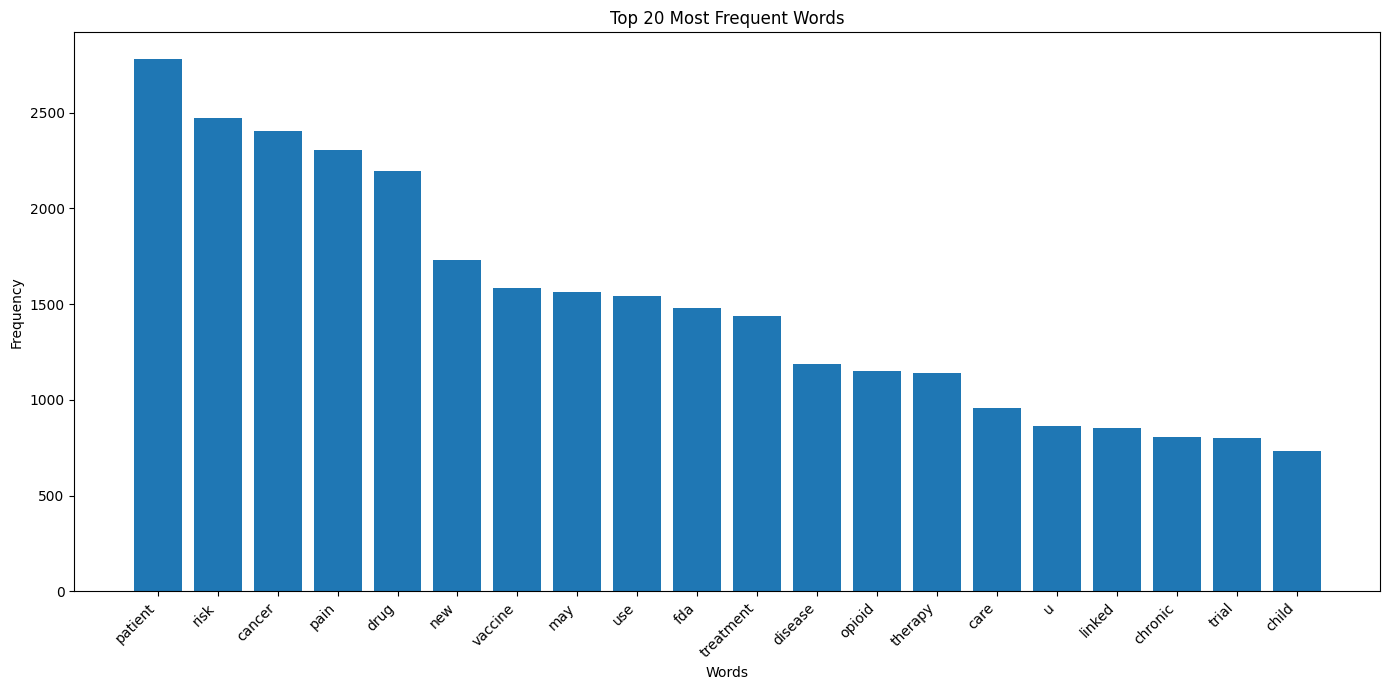

In [20]:
plt.figure(figsize=(14, 7))

plt.bar(words, frequencies)

plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
!pip install pyldavis scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 66.3 MB/s eta 0:00:00


In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [23]:
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words='english'
)

dtm = vectorizer.fit_transform(df['cleaned_text'])

print("Document-Term Matrix Shape:", dtm.shape)

Document-Term Matrix Shape: (39405, 10895)


In [24]:
lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)

lda_model.fit(dtm)

print("LDA model trained successfully.")

LDA model trained successfully.


In [25]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [
        feature_names[i]
        for i in topic.argsort()[:-6:-1]
    ]

    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_words))
    print()

Topic 1:
treatment, disease, drug, trial, new

Topic 2:
cancer, opioid, drug, antibiotic, use

Topic 3:
pain, patient, care, chronic, use

Topic 4:
vaccine, fda, cancer, drug, risk

Topic 5:
risk, effect, new, disease, smoking



In [26]:
topic_distribution = lda_model.transform(dtm)

df['dominant_topic'] = topic_distribution.argmax(axis=1) + 1

df[['Headlines', 'dominant_topic']].head(10)

,Headlines,dominant_topic
0,Special Report: Adult Vaccines -- New ACIP Rec...,4
1,Combined Internet and Telephone Intervention M...,3
2,Link Between Parental Alcoholism and Childhood...,4
3,Methadone Dose in the Treatment of Opiate Depe...,3
4,Magnet Treatment Had No Beneficial Effect on P...,3
5,Ask the Experts - Investigational Agents for M...,5
6,Estrogen Replacement May Negate the Benefits o...,1
7,MEDLINE Abstracts: Thalidomide Clinical Trials,4
8,IRB/FDA Requirements Relevant to HIV/AIDS Clin...,1
9,HIV Clinical Trials in Correctional Settings: ...,1


In [27]:
topic_counts = df['dominant_topic'].value_counts().sort_index()

print(topic_counts)

dominant_topic
1    7638
2    7440
3    8733
4    8078
5    7516
Name: count, dtype: int64


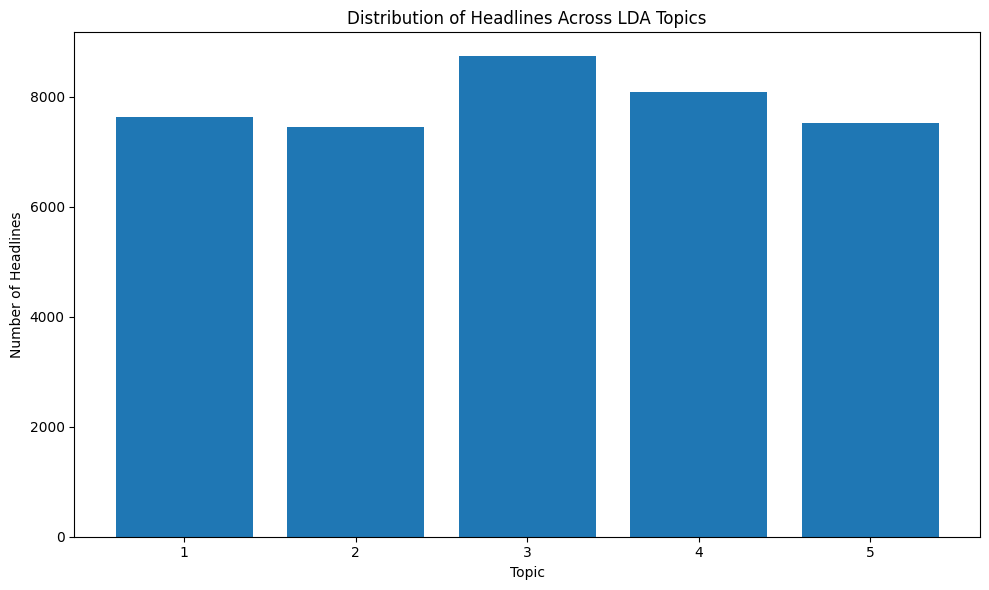

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    topic_counts.index.astype(str),
    topic_counts.values
)

plt.xlabel('Topic')
plt.ylabel('Number of Headlines')
plt.title('Distribution of Headlines Across LDA Topics')

plt.tight_layout()
plt.show()

In [29]:
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
lda_vis = pyLDAvis.lda_model.prepare(
    lda_model,
    dtm,
    vectorizer
)

lda_vis

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.225241 -0.045439       1        1  21.572689
3     -0.160519  0.108962       2        1  20.696130
0     -0.060986 -0.156014       3        1  19.374853
4     -0.064273 -0.101045       4        1  19.196867
1      0.060536  0.193536       5        1  19.159460, topic_info=          Term         Freq        Total Category  logprob  loglift
7000      pain  2171.000000  2171.000000  Default  30.0000  30.0000
10437  vaccine  1495.000000  1495.000000  Default  29.0000  29.0000
3600       fda  1399.000000  1399.000000  Default  28.0000  28.0000
1448      care   904.000000   904.000000  Default  27.0000  27.0000
1386    cancer  2296.000000  2296.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
6443       new   263.918445  1648.628484   Topic5  -5.0327  -0.1797
7112   patient   283.083107  2638.526004   Topic5  -4.9626  -0.5799
8490      risk   227.965359  2348.771710   Topic5  -5.1791  -0.6801
337    alcohol   169.462556   471.009971   Topic5  -5.4757   0.6301
10091    trial   152.676015   766.380765   Topic5  -5.5800   0.0390

[343 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
13         2  0.947112       aap
13         4  0.037884       aap
34         3  0.981152  ablation
54         1  0.376863     abuse
54         2  0.232080     abuse
...      ...       ...       ...
10845      1  0.007188      year
10845      2  0.548703      year
10845      3  0.064694      year
10845      4  0.055110      year
10845      5  0.325868      year

[573 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 1, 5, 2])

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

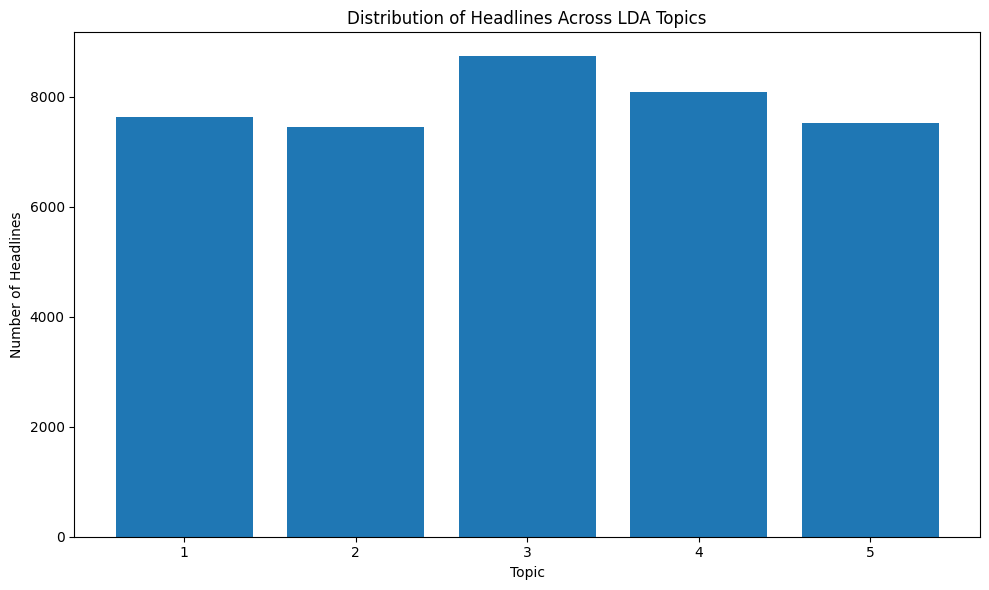

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [31]:
import matplotlib.pyplot as plt

topic_counts = df['dominant_topic'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    topic_counts.index.astype(str),
    topic_counts.values
)

plt.xlabel('Topic')
plt.ylabel('Number of Headlines')
plt.title('Distribution of Headlines Across LDA Topics')

plt.tight_layout()
plt.show()